In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv')

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Dataset shape
print("Dataset Shape:")
print(df.shape)

# Missing values
print("Missing Values:")
print(df.isnull().sum())

# Dataset information
print("Dataset Information:")
df.info()

First 5 Rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Dataset Shape:
(10000, 10)
Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non

In [4]:
# Check Class Balance

print("Target Value Counts:")
print(df['Target'].value_counts())

print("Target Distribution (%):")
print(df['Target'].value_counts(normalize=True) * 100)

Target Value Counts:
Target
0    9661
1     339
Name: count, dtype: int64
Target Distribution (%):
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


# Step 1.2 — Data Preparation

In [5]:
# Define features and target
X = df.drop(columns=['UDI', 'Product ID', 'Failure Type', 'Target'])

y = df['Target']

# Display feature columns
print("Feature Columns:")
print(X.columns)

# Display target column
print("Target Column:")
print(y.head())

Feature Columns:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')
Target Column:
0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64


# Step 1.3 — Encoding and Data Splitting

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical column
encoder = LabelEncoder()

X['Type'] = encoder.fit_transform(X['Type'])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8000, 6)
Testing set shape: (2000, 6)


# Step 1.4 — Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display scaled data shape
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)

Scaled training set shape: (8000, 6)
Scaled testing set shape: (2000, 6)


# Step 2 — Train Machine Learning Models

# Logistic Regression Evaluation

In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


Accuracy: 0.968
Precision: 0.6666666666666666
Recall: 0.11764705882352941
F1-Score: 0.2


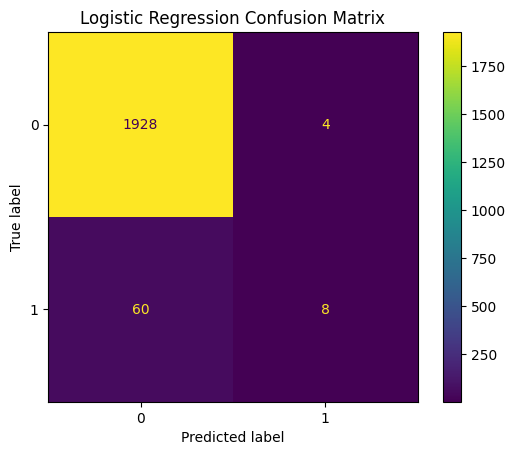

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluation metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# Print results
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-Score:", log_f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest Model

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
random_forest = RandomForestClassifier(random_state=42)

# Train the model
random_forest.fit(X_train_scaled, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


Accuracy: 0.985
Precision: 0.88
Recall: 0.6470588235294118
F1-Score: 0.7457627118644068


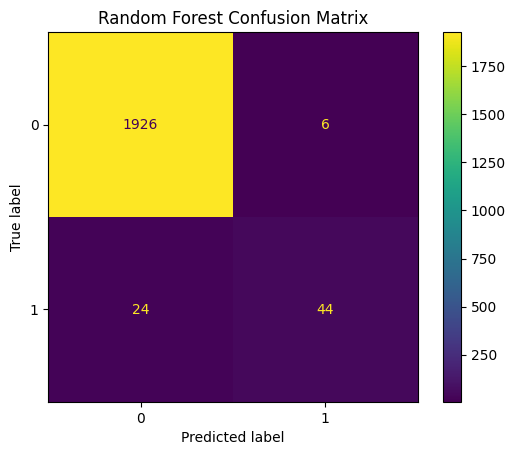

In [11]:
# Make predictions
y_pred_rf = random_forest.predict(X_test_scaled)

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Print results
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-Score:", rf_f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

# K-Nearest Neighbors (KNN) Model

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the model
knn = KNeighborsClassifier()

# Train the model
knn.fit(X_train_scaled, y_train)

print("KNN trained successfully.")

KNN trained successfully.


Accuracy: 0.974
Precision: 0.8333333333333334
Recall: 0.29411764705882354
F1-Score: 0.43478260869565216


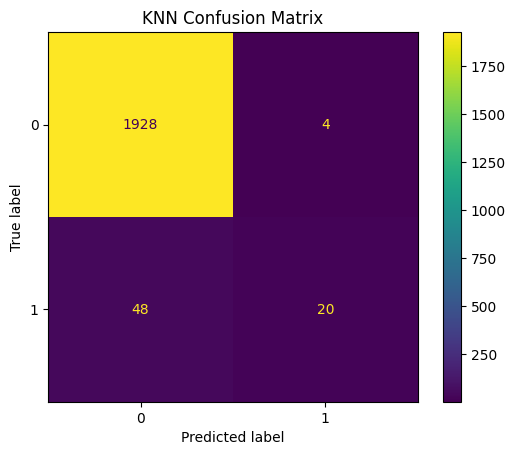

In [13]:
# Make predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

# Print results
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-Score:", knn_f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("KNN Confusion Matrix")
plt.show()

# Step 3 — Neural Network Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build the neural network
nn_model = Sequential()

# Input layer + hidden layer
nn_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Dropout layer
nn_model.add(Dropout(0.3))

# Second hidden layer
nn_model.add(Dense(16, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

2026-05-30 18:39:55.669800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780166395.870808      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780166395.930986      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780166396.402295      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780166396.402343      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780166396.402347      57 computation_placer.cc:177] computation placer alr

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-30 18:40:20.577771: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8116 - loss: 0.4560 - val_accuracy: 0.9656 - val_loss: 0.1636
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9666 - loss: 0.1660 - val_accuracy: 0.9656 - val_loss: 0.1435
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9642 - loss: 0.1528 - val_accuracy: 0.9656 - val_loss: 0.1302
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9643 - loss: 0.1321 - val_accuracy: 0.9656 - val_loss: 0.1196
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9693 - loss: 0.1109 - val_accuracy: 0.9656 - val_loss: 0.1121
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.1084 - val_accuracy: 0.9688 - val_loss: 0.1053
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9673 - loss: 0.1129 - val_accuracy: 0.9681 - val_loss: 0.1035
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9698 - loss: 0.1044 - val_accuracy: 0.9681 - val_

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities
y_pred_nn = nn_model.predict(X_test_scaled)

# Convert probabilities to binary predictions
y_pred_nn = (y_pred_nn > 0.5).astype(int)

# Evaluation metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

# Print results
print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-Score:", nn_f1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9695
Precision: 0.8181818181818182
Recall: 0.1323529411764706
F1-Score: 0.22784810126582278


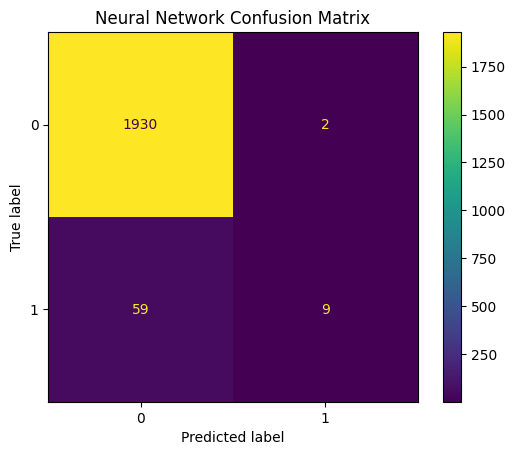

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Neural Network Confusion Matrix")
plt.show()

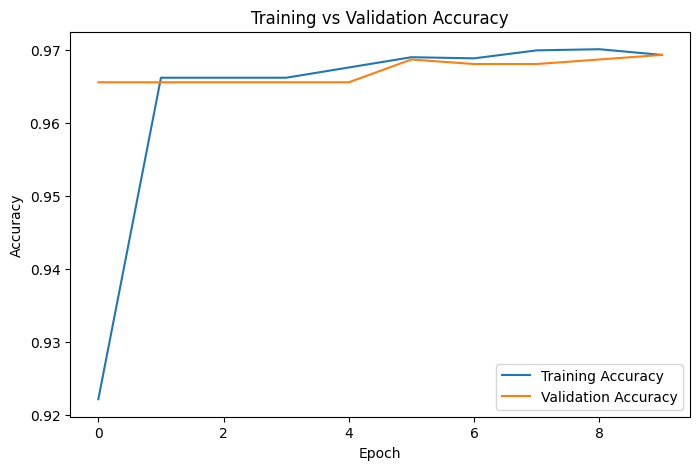

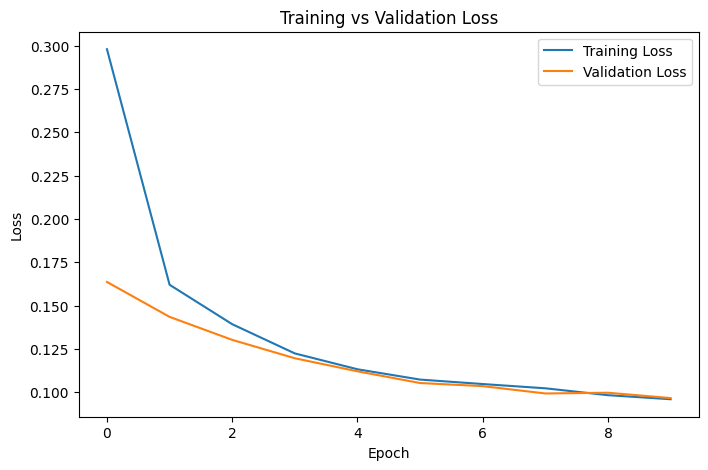

In [17]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 4 — Model Comparison

In [18]:
# Create comparison table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN',
        'Neural Network'
    ],
    
    'Accuracy': [
        log_accuracy,
        rf_accuracy,
        knn_accuracy,
        nn_accuracy
    ],
    
    'Precision': [
        log_precision,
        rf_precision,
        knn_precision,
        nn_precision
    ],
    
    'Recall': [
        log_recall,
        rf_recall,
        knn_recall,
        nn_recall
    ],
    
    'F1-Score': [
        log_f1,
        rf_f1,
        knn_f1,
        nn_f1
    ]
})

# Display results
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9680,0.666667,0.117647,0.200000
1,Random Forest,0.9850,0.880000,0.647059,0.745763
2,KNN,0.9740,0.833333,0.294118,0.434783
3,Neural Network,0.9695,0.818182,0.132353,0.227848


In [19]:
# Save the Trained Model

In [20]:
import joblib

# Save the trained Random Forest model
joblib.dump(random_forest, 'random_forest_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
